# Logistic Regression - In-depth analysis

### Following the supervised benchmark in `Notebook_05`, Logistic Regression and Random Forest were retained for a more detailed analysis. This notebook focuses on Logistic Regression.

The objective of this notebook is to investigate a small set of hyperparameters that are directly related to the statistical behaviour of the model, such as :

1. **Regularization type (`L1` vs `L2`)**
2. **Regularization strength (`C`)**
3. **Decision threshold** as an exploratory post-processing step

The two prediction settings defined in the previous notebooks are kept :

1. **Selected risk-factor features only**
2. **Selected features including screening tests** (`Hinselmann`, `Schiller`, `Citology`)

Model development is performed on the training data. 

The test set is  left untouched and will be used only once, after both Logistic Regression and Random Forest have been optimized, for the final model comparison.

The primary model-selection metric remains PR-AUC / Average Precision, because only a small proportion of biopsies are positive. ROC-AUC, recall, precision, F1-score, balanced accuracy and MCC are retained as complementary metrics.

### 1. Import libraries + training data

The feature subsets used here are the outputs of the previous feature-selection notebook. No additional feature selection is performed in this notebook.

A limitation to keep in mind before going further, is that RFECV in the previous notebook used a Logistic Regression estimator. The selected feature subsets may therefore partly favour linear models. This point should be considered when comparing Logistic Regression with Random Forest later.

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV, cross_validate, cross_val_predict)
from sklearn.metrics import (make_scorer, precision_score, recall_score, f1_score, balanced_accuracy_score, matthews_corrcoef, ConfusionMatrixDisplay, confusion_matrix)

RANDOM_STATE = 28

SELECTED_DIR = Path("../01_DATA/selected")
PLOTS_DIR = Path("../04_FIGURES")
RESULTS_DIR = Path("../05_RESULTS")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

risk_train = pd.read_csv(SELECTED_DIR / "x_train_selected.csv")
diag_train = pd.read_csv(SELECTED_DIR / "diag_x_train_selected.csv")

y_risk = risk_train["Biopsy"]
X_risk = risk_train.drop(columns="Biopsy")

y_diag = diag_train["Biopsy"]
X_diag = diag_train.drop(columns="Biopsy")

assert y_risk.equals(y_diag)
y = y_risk

print("\n Risk-factor dataset :", X_risk.shape)
print(X_risk.columns.tolist())

print("\n Diagnostic-inclusive dataset :", X_diag.shape)
print(X_diag.columns.tolist())

print("\n Target distribution :")
print(y.value_counts())


 Risk-factor dataset : (584, 13)
['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs (number)', 'STDs:syphilis', 'STDs:HIV', 'Dx:CIN', 'Dx:HPV', 'Dx', 'smokes_missing', 'hormonal_contraceptives_missing', 'number_of_sexual_partners_missing', 'num_of_pregnancies_missing']

 Diagnostic-inclusive dataset : (584, 6)
['STDs:syphilis', 'Dx:CIN', 'Hinselmann', 'Schiller', 'Citology', 'hormonal_contraceptives_missing']

 Target distribution :
Biopsy
0    546
1     38
Name: count, dtype: int64


### 2. Evaluation strategy

Hyperparameter tuning and performance estimation should be separated.

If the same cross-validation folds are used both to select the best hyperparameters and to report the final performance, the estimated performance can become optimistic. To limit this bias, a nested cross-validation strategy is used here :

- **Inner CV :** selects the Logistic Regression hyperparameters using PR-AUC
- **Outer CV :** estimates the generalisation performance of the full tuning procedure

The outer loop uses repeated stratified 5-fold CV to obtain a more stable estimate despite the small number of positive biopsies. The inner loop uses stratified 5-fold CV.

In [9]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

scoring = {"PR_AUC": "average_precision",
           "ROC_AUC": "roc_auc",
           "Recall": "recall",
           "Precision": make_scorer(precision_score, zero_division = 0), #to avoid having warnings output when the model predicts no positive
           "F1": "f1",
           "Balanced_accuracy": "balanced_accuracy",
           "MCC": make_scorer(matthews_corrcoef)}


### 3. Logistic Regression pipeline

The model is fitted inside a `Pipeline` containing `StandardScaler`.

The scaler is included in the pipeline to prevent data leakage and to ensure that regularization treats predictors on a comparable scale.

`class_weight="balanced"` is kept fixed because the previous class-imbalance analysis showed that class weighting performed better than SMOTE for this dataset. It is therefore treated as an already justified preprocessing/modeling choice rather than a new hyperparameter to tune.

The `liblinear` solver is used because the problem is binary, the dataset is small, and this solver supports both **L1 and L2 penalties**. 
`max_iter` is set high enough to ensure convergence, while the intercept and solver are kept fixed to avoid expanding the search space with parameters that are not central to our clinical question.

In [15]:
logistic_pipeline = Pipeline([("scaler", StandardScaler()), ("classifier", LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=5000, random_state=RANDOM_STATE))])

### 4. Hyperparameters investigation

Only two hyperparameters are tuned.

#### Regularization penalty

- **L1 penalty** can shrink some coefficients exactly to zero and therefore produces a sparse model. This can be useful when only a subset of the selected variables contributes meaningfully to prediction
- **L2 penalty** shrinks coefficients toward zero without usually removing variables completely. It is more stable when predictors are correlated

Testing both penalties is relevant here because the previous feature-selection step reduced the dimensionality, but redundancy between biological variables may still remain.

#### Regularization strength `C`

A logarithmic grid is used because the scale of `C` is multiplicative rather than linear. The tested range spans very strong to weak regularization without creating an unnecessarily large search space.

In [16]:
param_grid = {"classifier__l1_ratio": [0.0, 1.0], "classifier__C": np.logspace(-3, 2, 6)} #l1_ratio=0 -> L2 / l1_ratio=1 -> L1
param_grid

{'classifier__l1_ratio': [0.0, 1.0],
 'classifier__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])}

### 5. Nested cross-validation

The function below performs the same analysis for each feature scenario.

`GridSearchCV` performs hyperparameter selection in the inner CV using **Average Precision (PR-AUC)**. The entire search object is then evaluated by the outer repeated CV.

The output therefore reflects the performance of the complete model-development procedure, not only the performance of one configuration chosen after looking at all training data.

In [17]:
def nested_logistic_cv(X, y):
    search = GridSearchCV(estimator=logistic_pipeline, param_grid=param_grid, scoring="average_precision", cv=inner_cv, refit=True)
    nested_scores = cross_validate(estimator=search, X=X, y=y, cv=outer_cv, scoring=scoring, return_estimator=True)
    return nested_scores

In [ ]:
risk_nested = nested_logistic_cv(X_risk, y_risk)
diag_nested = nested_logistic_cv(X_diag, y_diag)

risk_nested.keys() #check if the function runs well

dict_keys(['fit_time', 'score_time', 'estimator', 'test_PR_AUC', 'test_ROC_AUC', 'test_Recall', 'test_Precision', 'test_F1', 'test_Balanced_accuracy', 'test_MCC'])

### 6. Cross-validated performance

Mean and standard deviation are reported for comparison, while median, minimum and maximum are also saved to document the variability across the repeated outer folds.

PR-AUC remains the primary metric. MCC and recall are particularly useful complementary metrics because they summarize threshold-based classification performance under strong class imbalance.

In [19]:
def summarize_nested_scores(nested_scores):
    rows = []
    for metric in scoring:
        values = nested_scores[f"test_{metric}"]
        rows.append({"Metric": metric,
                     "Mean": values.mean(),
                     "Std": values.std(),
                     "Median": np.median(values),
                     "Min": values.min(),
                     "Max": values.max()})
    return pd.DataFrame(rows).set_index("Metric")

risk_summary = summarize_nested_scores(risk_nested)
diag_summary = summarize_nested_scores(diag_nested)

display(risk_summary.round(3))
display(diag_summary.round(3))

risk_summary.to_csv(RESULTS_DIR / "logistic_nested_cv_risk.csv")
diag_summary.to_csv(RESULTS_DIR / "logistic_nested_cv_diag.csv")


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.129,0.035,0.123,0.074,0.192
ROC_AUC,0.613,0.096,0.650,0.394,0.747
Recall,0.437,0.181,0.500,0.125,0.750
Precision,0.102,0.039,0.111,0.018,0.160
F1,0.161,0.060,0.171,0.032,0.250
Balanced_accuracy,0.572,0.095,0.595,0.319,0.689
MCC,0.083,0.101,0.105,-0.172,0.219


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.699,0.171,0.711,0.450,0.975
ROC_AUC,0.944,0.065,0.979,0.732,0.999
Recall,0.905,0.097,0.875,0.714,1.000
Precision,0.545,0.099,0.538,0.400,0.800
F1,0.675,0.087,0.667,0.526,0.889
Balanced_accuracy,0.925,0.049,0.915,0.825,0.991
MCC,0.674,0.090,0.659,0.509,0.886


In [ ]:
def compact_summary(risk_summary, diag_summary):
    metrics = ["PR_AUC", "MCC", "Recall", "Precision", "F1", "ROC_AUC"]
    table = pd.DataFrame(index=metrics)
    table["Selected risk factors"] = [
        f"{risk_summary.loc[m, 'Mean']:.3f} ± {risk_summary.loc[m, 'Std']:.3f}"
        for m in metrics]
    table["Selected + diagnostics"] = [
        f"{diag_summary.loc[m, 'Mean']:.3f} ± {diag_summary.loc[m, 'Std']:.3f}"
        for m in metrics]
    return table

logistic_slide_table = compact_summary(risk_summary, diag_summary)
logistic_slide_table

,Selected risk factors,Selected + diagnostics
PR_AUC,0.129 ± 0.035,0.699 ± 0.171
MCC,0.083 ± 0.101,0.674 ± 0.090
Recall,0.437 ± 0.181,0.905 ± 0.097
Precision,0.102 ± 0.039,0.545 ± 0.099
F1,0.161 ± 0.060,0.675 ± 0.087
ROC_AUC,0.613 ± 0.096,0.944 ± 0.065


### 7. Stability of hyperparameter selection

A single best value of `C` can be misleading when the dataset is small. Therefore, the hyperparameters selected in each outer fold are inspected.

If the same penalty and similar values of `C` are selected repeatedly, the tuning result is more stable. Conversely, large variation between folds would indicate substantial uncertainty in the optimal configuration.

In [21]:
def extract_best_params(nested_scores):
    return pd.DataFrame([est.best_params_
        for est in nested_scores["estimator"]])

risk_best_params = extract_best_params(risk_nested)
diag_best_params = extract_best_params(diag_nested)

print("Risk factors only:")
display(risk_best_params.value_counts().rename("Count").reset_index())

print("\nSelected + diagnostics:")
display(diag_best_params.value_counts().rename("Count").reset_index())

risk_best_params.to_csv(RESULTS_DIR / "logistic_best_params_outer_folds_risk.csv", index=False)

diag_best_params.to_csv(RESULTS_DIR / "logistic_best_params_outer_folds_diag.csv", index=False)

Risk factors only:


,classifier__C,classifier__l1_ratio,Count
0,0.001,0.0,18
1,100.000,0.0,2
2,100.000,1.0,1
3,1.000,0.0,1
4,1.000,1.0,1
5,0.100,1.0,1
6,0.100,0.0,1



Selected + diagnostics:


,classifier__C,classifier__l1_ratio,Count
0,0.001,0.0,8
1,0.010,0.0,7
2,10.000,0.0,4
3,1.000,0.0,3
4,0.100,0.0,3


L2 was selected very consistently across outer folds, whereas the optimal value of C showed more variability.

### 8. Final hyperparameter search on the training set

Nested CV is used to estimate performance. After this, `GridSearchCV` is fitted on the training set to determine the configuration that will later be trained before the held-out test evaluation.

This doesn't evaluate the final model on the test set : it only freezes the hyperparameters.

In [22]:
def fit_final_search(X, y):
    search = GridSearchCV(estimator = logistic_pipeline, param_grid = param_grid, scoring = "average_precision", cv = inner_cv, refit = True, return_train_score = True)
    #refit = True retrains the best hyperparameter configuration on training data after CV
    search.fit(X, y)
    return search

risk_search = fit_final_search(X_risk, y)
diag_search = fit_final_search(X_diag, y)

print("Risk factors only")
print("Best parameters:", risk_search.best_params_)
print("Best inner-CV PR-AUC:", round(risk_search.best_score_, 3))

print("\nSelected + diagnostics")
print("Best parameters:", diag_search.best_params_)
print("Best inner-CV PR-AUC:", round(diag_search.best_score_, 3))


Risk factors only
Best parameters: {'classifier__C': np.float64(0.01), 'classifier__l1_ratio': 0.0}
Best inner-CV PR-AUC: 0.133

Selected + diagnostics
Best parameters: {'classifier__C': np.float64(0.001), 'classifier__l1_ratio': 0.0}
Best inner-CV PR-AUC: 0.694


The optimal hyperparameters appears to be C = 0.001 and L2 penalty.

In [ ]:
best_params_to_save = {"risk_factors": risk_search.best_params_, "selected_plus_diagnostics": diag_search.best_params_}

#keep a reproducible record of the selected hyperparameters to reuse them during final evaluation on test set
with open(RESULTS_DIR / "logistic_best_hyperparameters.json", "w") as f:
    json.dump(best_params_to_save, f, indent=2)


### 9. Effect of regularization strength

The tuning curves show how the choice of regularization type (`L1` or `L2`) and regularization strength (`C`) affects inner-CV PR-AUC, while final performance must still be judged from the outer nested-CV results.

In [40]:
def plot_regularization_curve(search, scenario_name, filename):
    cv_results = pd.DataFrame(search.cv_results_)
    fig, ax = plt.subplots(figsize=(7, 5))
    for l1_ratio, label in [(0.0, "L2"), (1.0, "L1")]:
        subset = cv_results[cv_results["param_classifier__l1_ratio"].astype(float) == l1_ratio].copy()
        subset = subset.sort_values("param_classifier__C")
        ax.plot(subset["param_classifier__C"].astype(float), subset["mean_test_score"], marker="o", label=label)
        ax.fill_between(subset["param_classifier__C"].astype(float), subset["mean_test_score"] - subset["std_test_score"], subset["mean_test_score"] + subset["std_test_score"], alpha=0.15)
    
    ax.set_xscale("log")
    ax.set_xlabel("C (inverse regularization strength)")
    ax.set_ylabel("Mean inner-CV PR-AUC")
    ax.set_title(f"Logistic Regression regularization : {scenario_name}")
    ax.legend(title="Penalty")
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

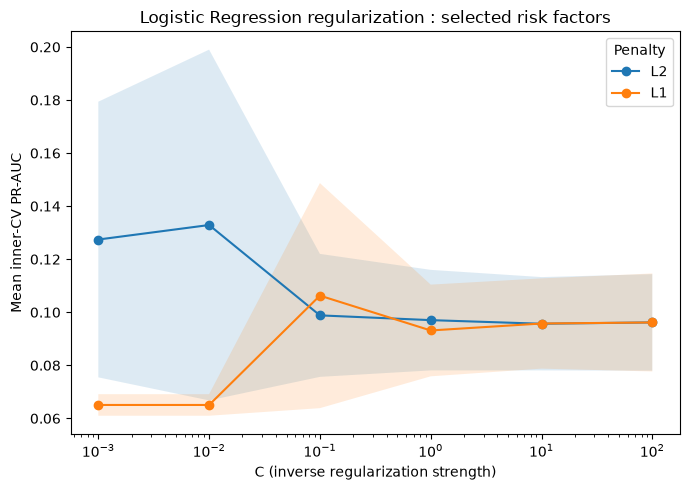

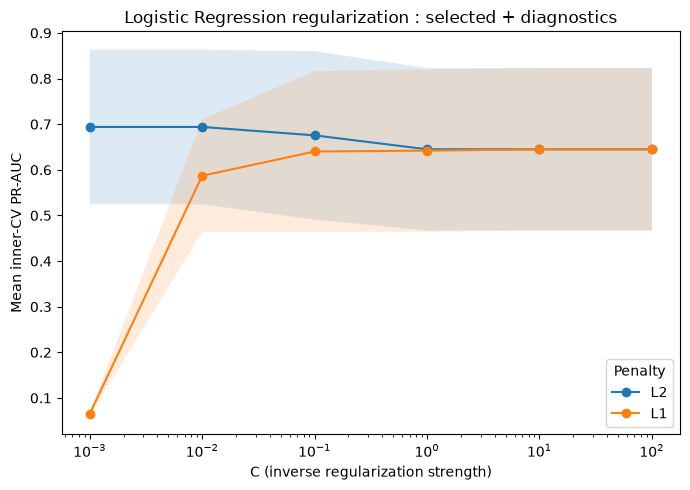

In [41]:
plot_regularization_curve(risk_search, "selected risk factors", "logistic_regularization_curve_risk.png")
plot_regularization_curve(diag_search, "selected + diagnostics", "logistic_regularization_curve_diag.png")

L2 is clearly preferred, especially with strong regularization (C = 0.001–0.01), with a PR-AUC value of approximately 0.69. 

L1 performs very poorly at C = 0.001, then improves as regularization decreases, plateauing around 0.64. From C ≈ 1 onwards, L1 and L2 become nearly equivalent.

Therefore, the model appears to benefit from fairly strong L2 regularization, although the large shaded areas indicate significant variability across the folds.

### 10. Coefficient stability across outer folds

Interpretability is one of the main reasons Logistic Regression was retained after the benchmark.

Coefficient distributions are extracted from the best model of each outer fold to determine whether the direction and magnitude of a predictive association are stable across resampled training subsets.

The coefficients shown below are standardized coefficients (because predictors are standardized inside the pipeline). They indicate the direction and relative strength of predictive associations but shouldn't be interpreted as causal effects.

In [ ]:
def extract_outer_coefficients(nested_scores, feature_names):
    rows = []
    for fold, search in enumerate(nested_scores["estimator"], start=1):
        best_model = search.best_estimator_
        coef = best_model.named_steps["classifier"].coef_[0]
        for feature, value in zip(feature_names, coef):
            rows.append({"Outer_fold": fold,
                         "Feature": feature,
                         "Coefficient": value})
    return pd.DataFrame(rows)

risk_coef = extract_outer_coefficients(risk_nested, X_risk.columns)
diag_coef = extract_outer_coefficients(diag_nested, X_diag.columns)

risk_coef.to_csv(RESULTS_DIR / "logistic_outer_fold_coefficients_risk.csv", index=False)
diag_coef.to_csv(RESULTS_DIR / "logistic_outer_fold_coefficients_diag.csv", index=False)

/var/folders/yk/85p787vn75q8thqfs1667snc0000gp/T/ipykernel_12476/3771374496.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert = False, tick_labels = features, patch_artist = True)


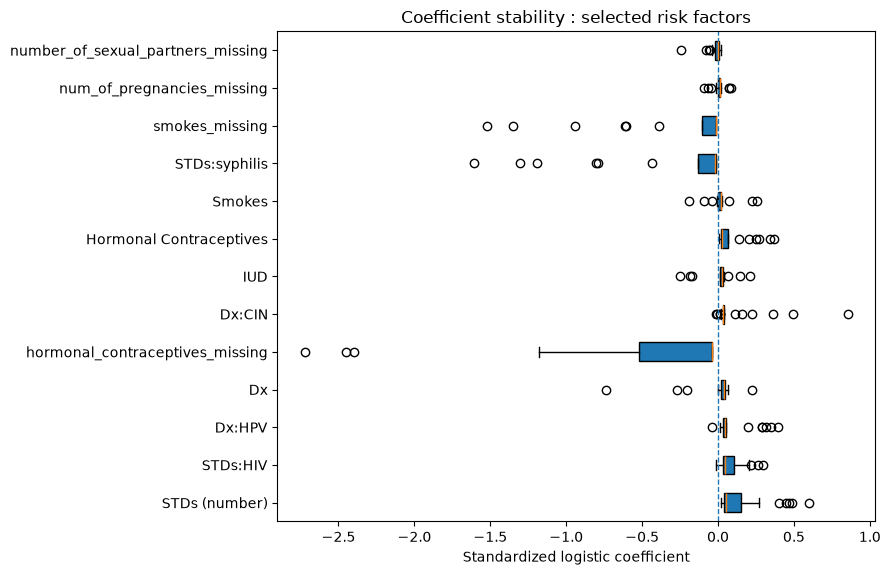

/var/folders/yk/85p787vn75q8thqfs1667snc0000gp/T/ipykernel_12476/3771374496.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert = False, tick_labels = features, patch_artist = True)


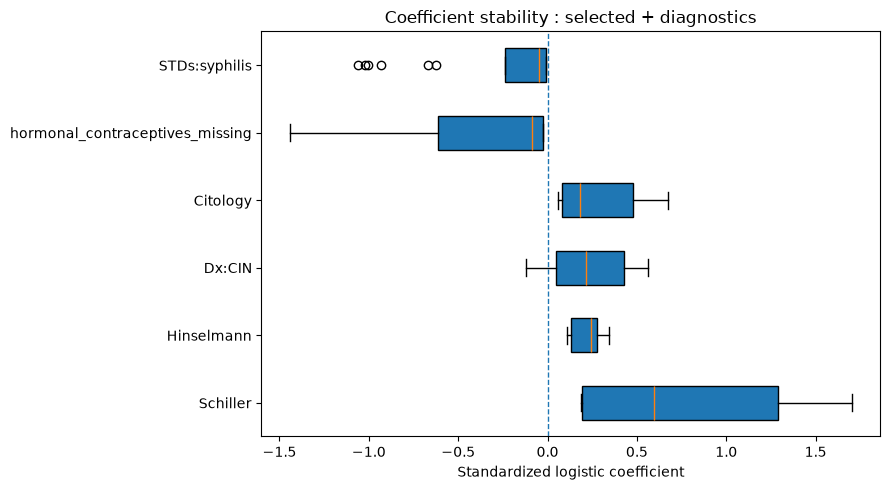

In [42]:
def plot_coefficient_stability(coef_df, scenario_name, filename):
    features = (coef_df.groupby("Feature")["Coefficient"].apply(lambda x: np.median(np.abs(x))).sort_values(ascending=False).index.tolist())
    values = [coef_df.loc[coef_df["Feature"] == feature, "Coefficient"].values
        for feature in features]

    fig, ax = plt.subplots(figsize = (9, max(5, 0.45 * len(features))))
    ax.boxplot(values, vert = False, tick_labels = features, patch_artist = True)
    ax.axvline(0, linestyle = "--", linewidth = 1)
    ax.set_xlabel("Standardized logistic coefficient")
    ax.set_title(f"Coefficient stability : {scenario_name}")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_coefficient_stability(risk_coef, "selected risk factors", "logistic_coefficient_stability_risk.png")
plot_coefficient_stability(diag_coef, "selected + diagnostics", "logistic_coefficient_stability_diag.png")


Screening variables, particularly Schiller and Hinselmann, show consistently positive coefficients across folds. Whereas, some clinical and missingness variables exhibit greater instability. 

This supports the predictive importance of diagnostic tests while highlighting uncertainty for weaker predictors.

### 11. Coefficients of the final training-set model

The final tuned model is fitted on the complete training set. The standardized coefficients provide a concise interpretation of the variables that increase or decrease the model score and describe predictive associations within this dataset.

In [34]:
def final_coefficient_table(search, feature_names):
    model = search.best_estimator_
    coef = model.named_steps["classifier"].coef_[0]
    table = pd.DataFrame({"Feature": feature_names, "Standardized_coefficient": coef})
    table["Abs_coefficient"] = table["Standardized_coefficient"].abs()
    return table.sort_values("Abs_coefficient", ascending = False)

risk_final_coef = final_coefficient_table(risk_search, X_risk.columns)
diag_final_coef = final_coefficient_table(diag_search, X_diag.columns)

display(risk_final_coef.drop(columns = "Abs_coefficient").round(3))
display(diag_final_coef.drop(columns = "Abs_coefficient").round(3))

risk_final_coef.to_csv(RESULTS_DIR / "logistic_final_coefficients_risk.csv", index=False)

diag_final_coef.to_csv(RESULTS_DIR / "logistic_final_coefficients_diag.csv", index=False)

,Feature,Standardized_coefficient
10,hormonal_contraceptives_missing,-0.248
3,STDs (number),0.207
4,STDs:syphilis,-0.138
5,STDs:HIV,0.135
7,Dx:HPV,0.134
1,Hormonal Contraceptives,0.128
9,smokes_missing,-0.112
6,Dx:CIN,0.106
2,IUD,0.092
8,Dx,0.078


,Feature,Standardized_coefficient
3,Schiller,0.219
2,Hinselmann,0.138
4,Citology,0.088
1,Dx:CIN,0.049
5,hormonal_contraceptives_missing,-0.030
0,STDs:syphilis,-0.013


The final Logistic Regression model is mainly driven by the screening variables Schiller, Hinselmann and Citology, while the remaining predictors have weaker contributions.

### 12. Decision-threshold analysis

PR-AUC evaluates ranking performance across thresholds, but a final binary prediction requires a decision threshold.

The default threshold of 0.5 is not necessarily optimal in an imbalanced dataset, especially when class weighting is used. Therefore, an exploratory threshold analysis is performed using **out-of-fold predictions from the training data only**. In this approach, each patient is predicted by a model that did not see her during training. This serves much more realistic predictions for selecting the threshold.

The threshold maximizing MCC is identified as a statistical compromise between all four confusion-matrix components.

The selected threshold must be frozen before evaluating the final model on the held-out test set.

In [35]:
oof_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)


def get_nested_oof_probabilities(X, y):
    search = GridSearchCV(estimator = logistic_pipeline, param_grid = param_grid, scoring = "average_precision", cv = inner_cv, refit = True)
    probabilities = cross_val_predict(search, X, y, cv=oof_cv, method="predict_proba",)[:, 1]
    return probabilities

risk_oof_prob = get_nested_oof_probabilities(X_risk, y)
diag_oof_prob = get_nested_oof_probabilities(X_diag, y)

In [36]:
def threshold_table(y_true, probabilities):
    rows = []
    for threshold in np.arange(0.05, 0.96, 0.01):
        pred = (probabilities >= threshold).astype(int)
        rows.append({"Threshold": threshold,
                     "Precision": precision_score(y_true, pred, zero_division=0),
                     "Recall": recall_score(y_true, pred),
                     "F1": f1_score(y_true, pred),
                     "Balanced_accuracy": balanced_accuracy_score(y_true, pred),
                     "MCC": matthews_corrcoef(y_true, pred)})
    return pd.DataFrame(rows)

risk_thresholds = threshold_table(y, risk_oof_prob)
diag_thresholds = threshold_table(y, diag_oof_prob)

risk_best_threshold = risk_thresholds.loc[risk_thresholds["MCC"].idxmax()]
diag_best_threshold = diag_thresholds.loc[diag_thresholds["MCC"].idxmax()]

print("Risk factors — threshold maximizing MCC")
display(risk_best_threshold.round(3))

print("Selected + diagnostics — threshold maximizing MCC")
display(diag_best_threshold.round(3))


Risk factors — threshold maximizing MCC


Threshold            0.740
Precision            0.333
Recall               0.053
F1                   0.091
Balanced_accuracy    0.523
MCC                  0.111
Name: 69, dtype: float64

Selected + diagnostics — threshold maximizing MCC


Threshold            0.570
Precision            0.647
Recall               0.868
F1                   0.742
Balanced_accuracy    0.918
MCC                  0.730
Name: 52, dtype: float64

At Threshold = 0.57, the model detects approximately 87% of positive biopsies, and about 65% of positive predictions are truly positive. The MCC of 0.73 indicates a great overall balance.

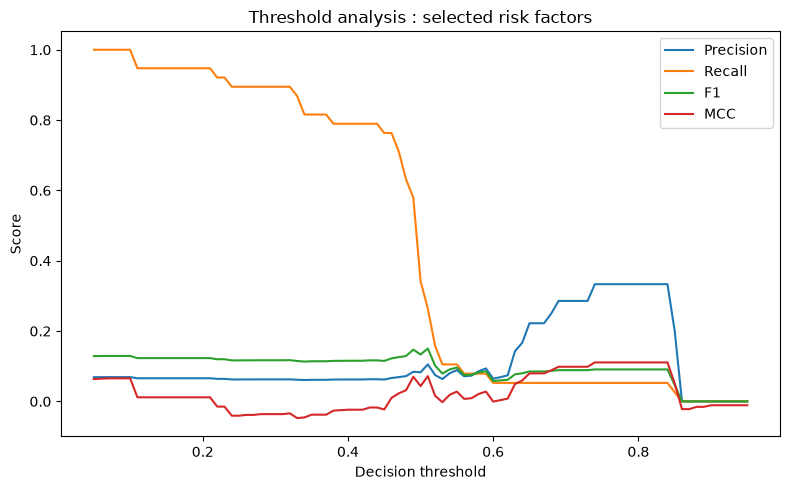

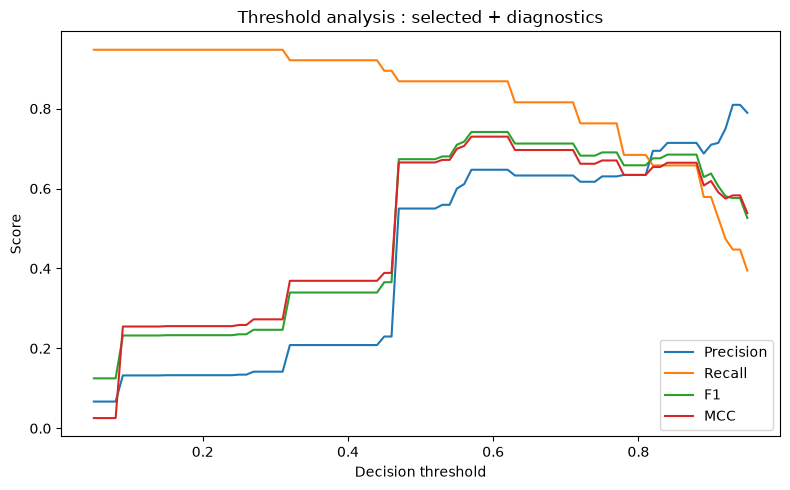

In [43]:
def plot_threshold_analysis(table, scenario_name, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for metric in ["Precision", "Recall", "F1", "MCC"]:
        ax.plot(table["Threshold"], table[metric], label=metric)
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"Threshold analysis : {scenario_name}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_threshold_analysis(risk_thresholds, "selected risk factors", "logistic_threshold_analysis_risk.png")
plot_threshold_analysis(diag_thresholds, "selected + diagnostics", "logistic_threshold_analysis_diag.png")

Threshold optimization showed that the diagnostic-inclusive model achieves a good precision–recall trade-off around 0.57. Around 0.55–0.60, F1 and MCC are close to their maximum values, so 0.57 is a reasonable compromise. Raising the threshold significantly would increase precision but result in too much loss of recall.

### 13. Out-of-fold confusion matrices

The confusion matrices below are also generated from out-of-fold training predictions. They are included as an interpretable complement to the cross-validated metrics.

These out-of-fold predictions provide an internal estimate of classification behaviour, but the held-out test set is required for the final unbiased evaluation.

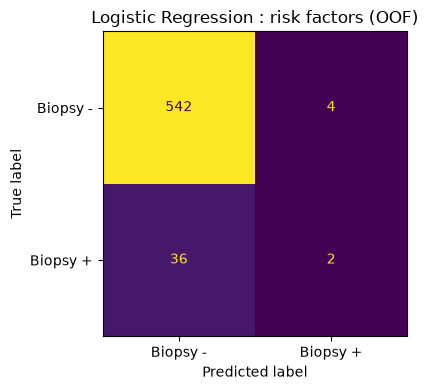

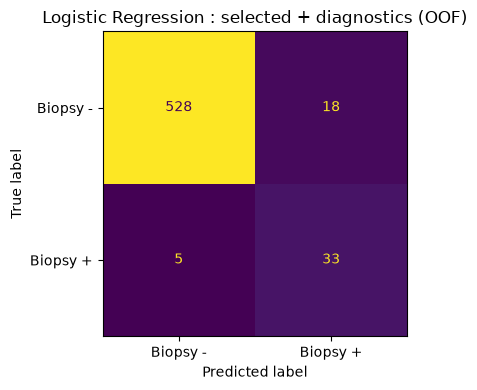

In [45]:
def plot_oof_confusion_matrix(y_true, probabilities, threshold, title, filename):
    pred = (probabilities >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ["Biopsy -", "Biopsy +"])

    disp.plot(ax = ax, colorbar = False)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches = "tight")
    plt.show()

plot_oof_confusion_matrix(y, risk_oof_prob, float(risk_best_threshold["Threshold"]), "Logistic Regression : risk factors (OOF)", "logistic_confusion_matrix_oof_risk.png")
plot_oof_confusion_matrix(y, diag_oof_prob, float(diag_best_threshold["Threshold"]), "Logistic Regression : selected + diagnostics (OOF)", "logistic_confusion_matrix_oof_diag.png")


Based on this oof confusion matrix :

- 528 true negatives (TN): negative biopsies correctly predicted as negative,
- 18 false positives (FP): negative biopsies predicted as positive,
- 5 false negatives (FN): positive biopsies missed,
- 33 true positives (TP): positive biopsies correctly detected.

For positive cases, the model detects 33 out of 38, representing a recall of approximately 87%. And among all positive predictions, 33 out of 51 are correct, representing a precision of approximately 65%. This is consistent with the metrics obtained at the chosen threshold.

The diagnostic-inclusive model detects the majority of positive biopsies, with relatively few false negatives but at the cost of some false positives.

## Interpretation and conclusion

This notebook evaluates Logistic Regression as one of the two methods selected after the supervised benchmark.

The analysis was focused on a limited number of choices that are directly relevant to this dataset :

- **L1 vs L2 regularization** to compare sparse and shrinkage-based solutions,
- **regularization strength `C`** to control the bias–variance trade-off,
- **class weighting**, retained from the previous imbalance analysis,
- **decision-threshold adjustment** as an exploratory post-processing step.

The nested cross-validation showed that **L2 regularization was consistently preferred**, particularly in the diagnostic-inclusive scenario, where it was selected in all outer folds. The optimal value of `C` was less stable across folds, suggesting some uncertainty regarding the exact strength of regularization. Nevertheless, the regularization curves indicate that relatively strong L2 regularization provides good predictive performance while limiting model complexity.

A clear difference was observed between the two feature scenarios. The **risk-factor-only model showed limited predictive ability**, and threshold optimization could not compensate for the lack of discriminative information. At the threshold maximizing MCC (0.74), recall was only 0.053 and MCC 0.111, indicating that most positive biopsies were still missed.

In contrast, the **diagnostic-inclusive model performed substantially better**. Using out-of-fold predictions, the threshold maximizing MCC was 0.57, with a precision of 0.647, recall of 0.868, F1-score of 0.742 and MCC of 0.730. The corresponding confusion matrix showed that 33 of the 38 positive biopsies were correctly identified, while only 5 were missed. These results indicate a much more useful discrimination between positive and negative biopsies when screening variables are included.

The coefficient analysis also provides an important interpretability advantage. **Schiller, Hinselmann and Citology showed consistently positive coefficients**, with `Schiller` having the largest contribution in the final fitted model. These results are consistent with the strong predictive information carried by cervical screening tests. In contrast, weaker predictors such as `STDs:syphilis` and the missingness indicator for hormonal contraceptives contributed little to the final model and showed greater instability across resampling.

However, these coefficients represent **predictive associations rather than causal effects**. Thus, negative coefficients should not be interpreted as protective biological effects.

Overall, **Logistic Regression appears to be a strong candidate for the diagnostic-inclusive prediction task**, combining good internal predictive performance, limited model complexity and straightforward interpretation. Its performance in the risk-factor-only scenario is much weaker, suggesting that the available upstream risk factors alone contain insufficient information for accurate biopsy prediction in this dataset.

The two scenarios therefore answer different questions: the risk-factor-only model evaluates prediction from upstream patient characteristics, whereas the diagnostic-inclusive model incorporates screening information that is much closer to the biopsy outcome.

### Next step - Notebook 07

The same level of analysis will be performed for Random Forest, focusing on hyperparameters controlling tree complexity and overfitting using the same nested cross-validation framework. Only after both methods have been optimized should the held-out test set be used for the final comparison in Notebook 08 based not only predictive performance, but also stability, complexity and biological interpretability.